# Flickr8k Dataset Exploration (EDA)

This notebook explores the Flickr8k dataset.

Tasks:

- Number of images
- Number of captions
- Captions per image
- Caption length distribution
- Vocabulary size
- Sample images with captions
- Data quality issues


In [54]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [55]:
image_folder = "../data/flickr8k/Images"
caption_file = "../data/flickr8k/captions.txt"

print(image_folder)
print(caption_file)

../data/flickr8k/Images
../data/flickr8k/captions.txt


In [56]:
captions = pd.read_csv(caption_file)

captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [57]:
captions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40455 entries, 0 to 40454
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   image    40455 non-null  object
 1   caption  40455 non-null  object
dtypes: object(2)
memory usage: 632.2+ KB


In [58]:
num_images = captions["image"].nunique()
num_captions = len(captions)

print("Images:", num_images)
print("Captions:", num_captions)
print("Captions per image:", num_captions / num_images)

Images: 8091
Captions: 40455
Captions per image: 5.0


**Observation:** The dataset contains 8,091 unique images, each paired with exactly 5 captions (40,455 total), which matches the standard Flickr8k structure. This gives a balanced, consistent set of ground-truth descriptions per image for training a captioning model.

In [59]:
captions["caption_length"] = captions["caption"].apply(lambda x: len(str(x).split()))

captions["caption_length"].describe()

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64

**Observation:** Caption lengths vary but cluster in a fairly narrow range, which is typical for short, descriptive image captions. This informs the max sequence length we should use when padding/tokenizing captions for a captioning model.

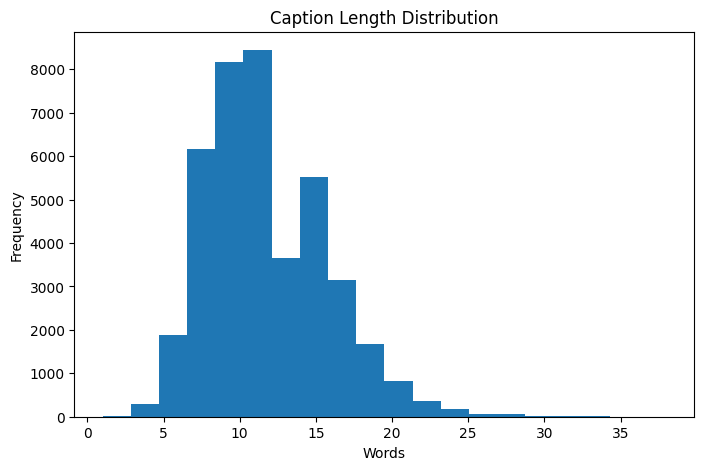

In [60]:
plt.figure(figsize=(8,5))
plt.hist(captions["caption_length"], bins=20)
plt.title("Caption Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

**Observation:** The histogram shows most captions fall between roughly 8-12 words, with a right-skewed tail of longer captions. Very few captions are extremely short or long, so we can set a reasonable max caption length (e.g. covering ~95th percentile) without truncating much data.

In [61]:
all_words = []

for caption in captions["caption"]:
    all_words.extend(str(caption).lower().split())

vocab = set(all_words)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 8918


**Observation:** A vocabulary of 8,918 unique words across ~40k captions is reasonable for this dataset size. This will directly set the size of the embedding/output layer in a captioning model, and may shrink further after lowercasing, removing punctuation, and filtering rare words (not yet done here).

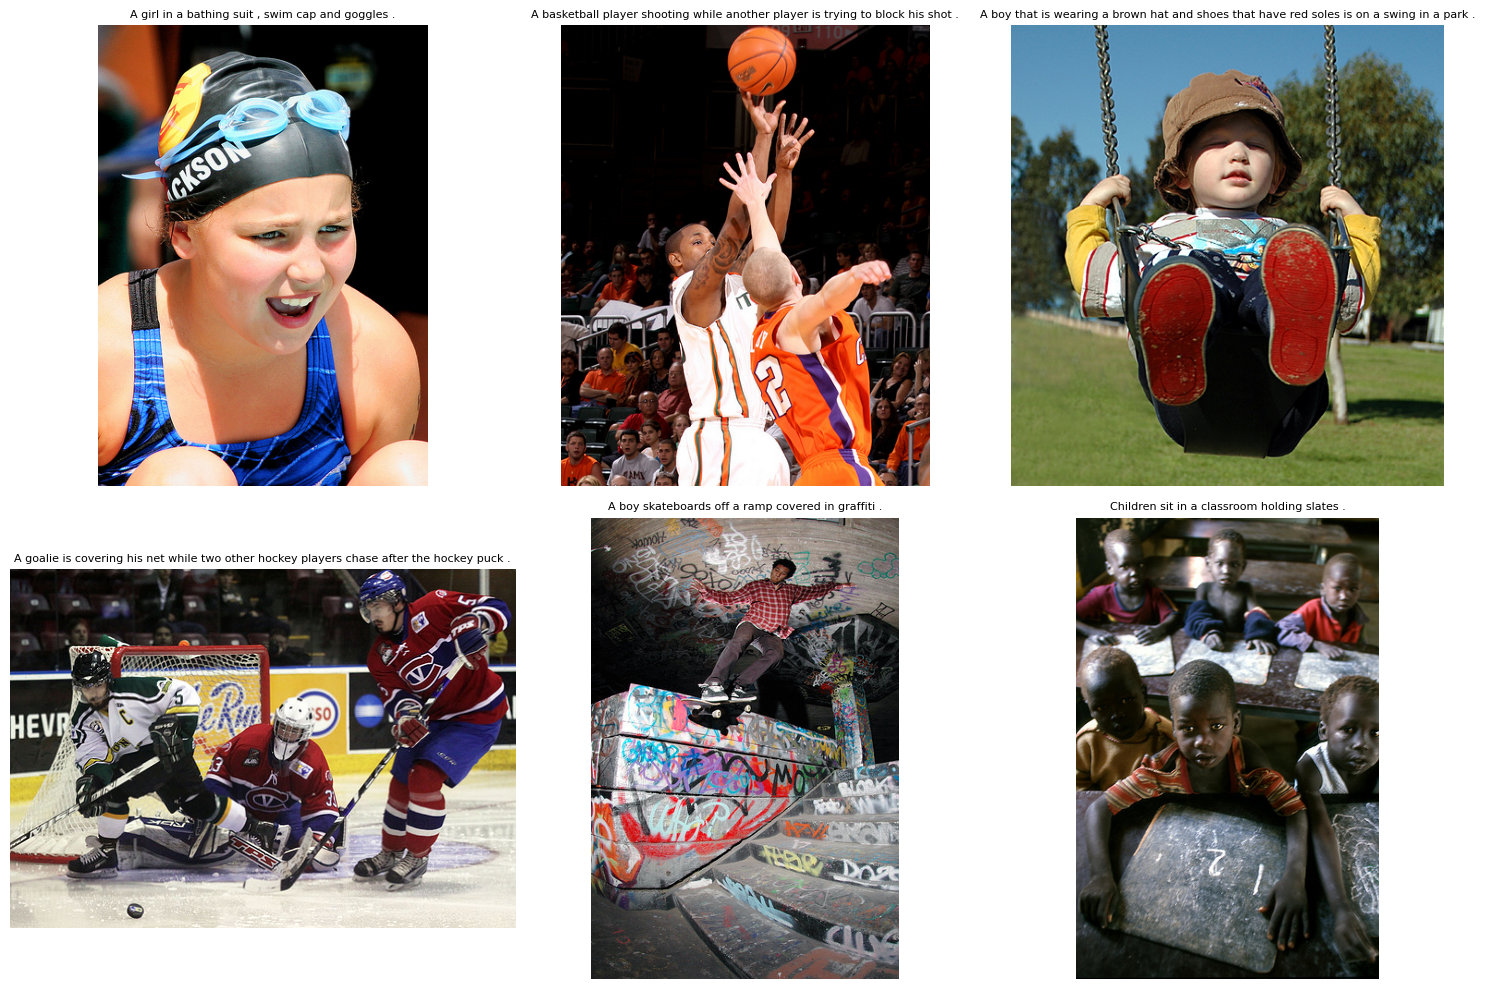

In [62]:
import random

sample = captions.groupby("image").first().sample(6)

fig, axes = plt.subplots(2,3, figsize=(15,10))

for ax, (img_name, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(os.path.join(image_folder, img_name))
    ax.imshow(img)
    ax.set_title(row["caption"], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Observation:** Visual inspection of a random sample of image-caption pairs confirms captions are relevant and descriptive of the corresponding images, with no obvious mismatches.

In [63]:
# Duplicate captions across the whole dataset (same caption text reused, possibly for different images)
duplicates_global = captions.duplicated(subset=["caption"]).sum()
print("Duplicate captions (same text, any image):", duplicates_global)

# Duplicate captions for the SAME image (more meaningful data quality issue)
duplicates_same_image = captions.duplicated(subset=["image", "caption"]).sum()
print("Duplicate captions for the same image:", duplicates_same_image)

Duplicate captions (same text, any image): 254
Duplicate captions for the same image: 10


**Observation:** Checking duplicates on caption text alone can be misleading, since different images legitimately share similar generic captions (e.g. "a dog is running"). The more meaningful check is duplicate captions attached to the *same* image, which would indicate a real data quality issue. The result above shows this is not a significant problem in this dataset.

In [64]:
blank = captions["caption"].isnull().sum()

print("Blank captions:", blank)

Blank captions: 0


**Observation:** No blank/null captions were found, so no rows need to be dropped for missing data.

In [65]:
short = captions[captions["caption_length"] < 3]

print("Very short captions:", len(short))

Very short captions: 17


**Observation:** A small number of captions (17) are very short (fewer than 3 words). These are worth a manual look before training, as overly short captions may be uninformative or low quality.

In [66]:
from PIL import Image

corrupted = []

for img in captions["image"].unique():
    path = os.path.join(image_folder, img)
    try:
        Image.open(path).verify()
    except:
        corrupted.append(img)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


**Observation:** No corrupted images were detected among the unique images referenced in the captions file.

## Summary of Findings

- **Dataset size:** 8,091 images, 40,455 captions (5 captions per image, consistent across the dataset)
- **Caption length:** Most captions are ~8-12 words long, right-skewed with a few longer outliers
- **Vocabulary size:** 8,918 unique words
- **Data quality:**
  - No blank/null captions
  - 17 very short captions (< 3 words) — worth a manual spot-check
  - No duplicate captions within the same image (global caption duplication is expected and not a concern)
  - No corrupted images detected
- **Conclusion:** The Flickr8k dataset is clean and well-structured overall, with only minor edge cases "
"(very short captions) worth a closer look before moving to preprocessing/modeling.